# MNIST Flow Matching Generation
This notebook trains a flow-matching velocity model on MNIST and generates digits from Gaussian noise by ODE integration.


## 1) Environment Check
This cell checks `torch`, `torchvision`, `matplotlib`, and `tqdm`, and tries to install missing packages automatically.


In [1]:
import importlib.util
import subprocess
import sys


def ensure_packages(packages):
    missing = [p for p in packages if importlib.util.find_spec(p) is None]
    if not missing:
        print("???????")
        return True

    print(f"???????: {missing}???????...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
        print("???????")
        return True
    except Exception as e:
        print("????????????????")
        print(f"????: {e}")
        return False

DEPENDENCIES_READY = ensure_packages(["torch", "torchvision", "matplotlib", "tqdm"])


???????


## 2) Imports And Config
This cell imports required libraries, sets random seeds, selects CPU/GPU, and defines core hyperparameters.


In [2]:
if DEPENDENCIES_READY:
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader
    from torchvision import datasets, transforms
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm

    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"????: {device}")

    batch_size = 128
    lr = 1e-3
    num_epochs = 5
    num_steps_sample = 100
else:
    print("???????????????????????")


????: cuda


c:\Users\napuc\anaconda3\envs\npcailab\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Load MNIST
This cell downloads and loads MNIST, then normalizes images to `[-1, 1]` for interpolation-based flow training.


In [3]:
if DEPENDENCIES_READY:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    train_set = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

    print(f"?????: {len(train_set)}")


?????: 60000


## 4) Build Flow Model
This cell defines a time-conditioned MLP velocity field `v_theta(x, t)` with sinusoidal time embedding.


In [4]:
if DEPENDENCIES_READY:
    class TimeEmbedding(nn.Module):
        def __init__(self, dim=64):
            super().__init__()
            self.dim = dim

        def forward(self, t):
            half = self.dim // 2
            freqs = torch.exp(
                torch.linspace(np.log(1.0), np.log(1000.0), half, device=t.device)
            )
            args = t[:, None] * freqs[None, :]
            return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


    class FlowMLP(nn.Module):
        def __init__(self, x_dim=28 * 28, t_dim=64, hidden=512):
            super().__init__()
            self.time_emb = TimeEmbedding(t_dim)
            self.net = nn.Sequential(
                nn.Linear(x_dim + t_dim, hidden),
                nn.SiLU(),
                nn.Linear(hidden, hidden),
                nn.SiLU(),
                nn.Linear(hidden, x_dim),
            )

        def forward(self, x, t):
            t_feat = self.time_emb(t)
            h = torch.cat([x, t_feat], dim=1)
            return self.net(h)


    model = FlowMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"?????: {sum(p.numel() for p in model.parameters()):,}")


?????: 1,099,536


## 5) Train With Flow Matching
This cell trains with the standard objective using `x_t=(1-t)x_0+t x_1` and target velocity `x_1-x_0`.


In [5]:
if DEPENDENCIES_READY:
    model.train()
    for epoch in range(num_epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0.0
        for x, _ in pbar:
            x1 = x.to(device).view(x.size(0), -1)
            x0 = torch.randn_like(x1)
            t = torch.rand(x1.size(0), device=device)

            xt = (1.0 - t[:, None]) * x0 + t[:, None] * x1
            target_v = x1 - x0

            pred_v = model(xt, t)
            loss = F.mse_loss(pred_v, target_v)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        print(f"Epoch {epoch+1}: mean loss = {total_loss / len(train_loader):.4f}")


Epoch 1/5: 100%|██████████| 468/468 [00:22<00:00, 21.13it/s, loss=1.0527]


Epoch 1: mean loss = 1.1463


Epoch 2/5: 100%|██████████| 468/468 [00:18<00:00, 25.75it/s, loss=0.9609]


Epoch 2: mean loss = 0.9994


Epoch 3/5: 100%|██████████| 468/468 [00:23<00:00, 20.24it/s, loss=0.9452]


Epoch 3: mean loss = 0.9470


Epoch 4/5: 100%|██████████| 468/468 [00:18<00:00, 25.51it/s, loss=0.9080]


Epoch 4: mean loss = 0.9210


Epoch 5/5: 100%|██████████| 468/468 [00:22<00:00, 20.64it/s, loss=0.8869]

Epoch 5: mean loss = 0.9055


## 6) Sample Digits
This cell starts from Gaussian noise and applies Euler integration of `dx/dt=v_theta(x,t)` to generate images.


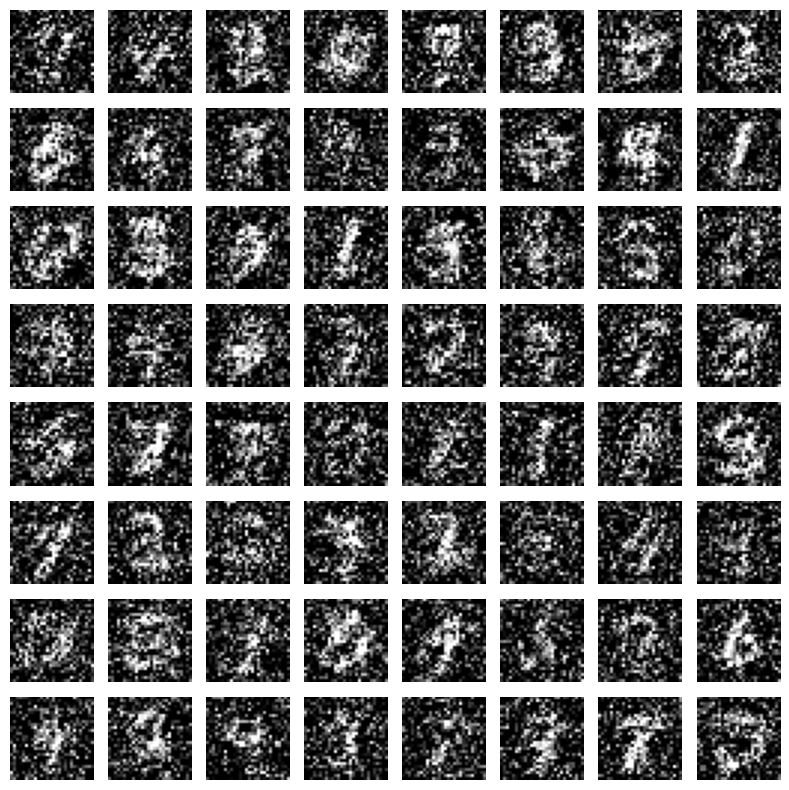

In [6]:
if DEPENDENCIES_READY:
    @torch.no_grad()
    def sample_flow(model, n_samples=64, steps=100):
        model.eval()
        x = torch.randn(n_samples, 28 * 28, device=device)
        dt = 1.0 / steps
        for i in range(steps):
            t = torch.full((n_samples,), i / steps, device=device)
            v = model(x, t)
            x = x + dt * v
        x = x.view(-1, 1, 28, 28)
        x = x.clamp(-1, 1)
        x = (x + 1) / 2
        return x.cpu()


    samples = sample_flow(model, n_samples=64, steps=num_steps_sample)

    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 7) Save Model (Optional)
This cell saves trained weights for future sampling or continued training.


In [7]:
if DEPENDENCIES_READY:
    save_path = "flow_matching_mnist.pt"
    torch.save(model.state_dict(), save_path)
    print(f"??????: {save_path}")


??????: flow_matching_mnist.pt
